#EMBEDDING WITH SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

In [ ]:
#!pip install ipywidgets --q

In [ ]:
# !pip install sentence-transformers xgboost scikit-learn pandas optuna tensorboard joblib --q

In [1]:
#Check directory
import os
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  e:\KLTN\Data_mining\new_data\nop


In [2]:
# import pandas as pd
# pd.set_option('display.max_colwidth', None)

In [2]:
# Đọc dữ liệu, kiểm tra tồn tại file trước khi đọc
import pandas as pd

file_path = 'data.csv'

df = pd.read_csv(file_path)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86271 entries, 0 to 86270
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Project_ID        86271 non-null  int64  
 1   Issue_Key         86271 non-null  object 
 2   Type              86271 non-null  object 
 3   Status            86271 non-null  object 
 4   Priority          86271 non-null  object 
 5   Title             86271 non-null  object 
 6   Description       86184 non-null  object 
 7   Description_Text  86184 non-null  object 
 8   Description_Code  13092 non-null  object 
 9   Story_Point       86271 non-null  float64
dtypes: float64(1), int64(1), object(8)
memory usage: 6.6+ MB


In [4]:
df.head()

,Project_ID,Issue_Key,Type,Status,Priority,Title,Description,Description_Text,Description_Code,Story_Point
0,1,XD-3765,FEATURE,Done,MEDIUM,"""Fix stream failover ""","""See https://github.com/spring-projects/spring...","""""""See https://github.com/spring-projects/spri...",NaN,8.0
1,1,XD-3748,BUG,Done,MEDIUM,"""Unable to register the JMX bean MessageHistor...","""If I try to use <int:message-history/> when d...","""""""If I try to use <int:message-history/> when...",""" 2016-02-24T10:40:39+0000 1.3.1.RELEASE ERROR...",1.0
2,1,XD-3747,IMPROVEMENT,Done,MEDIUM,"""Rabbit Bus: Expose ChannelCacheSize on Cachin...","""http://stackoverflow.com/questions/35563064/p...","""""""http://stackoverflow.com/questions/35563064...",NaN,1.0
3,1,XD-3746,IMPROVEMENT,Done,MEDIUM,"""Update Spring Framework to 4.2.4""","""Update Spring Framework to 4.2.4""","""Update Spring Framework to 4.2.4""",NaN,1.0
4,1,XD-3745,IMPROVEMENT,Done,MEDIUM,"""Update Spring-AMQP to 3.6, RabbitMQ Client to...","""Update to amqp-client 3.6.0 and spring-amqp 1...","""""""Update to amqp-client 3.6.0 and spring-amqp...",NaN,1.0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Project_ID,86271.0,22.199522,14.251779,1.0,12.0,23.0,36.0,44.0
Story_Point,86271.0,623.511834,128604.378899,0.0,1.0,3.0,5.0,26710114.0


In [6]:
df.duplicated().sum()

np.int64(334)

In [7]:
# Xóa các dữ liệu issue trùng lặp
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [8]:
# Kiểm tra giá trị null -- Description bị null không sao, 
#       Phần train sẽ chỉ lấy mỗi combined_text (title + desc) 
#       hoặc có thể bỏ các dòng dữ liệu đó luôn
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Project_ID              0
Issue_Key               0
Type                    0
Status                  0
Priority                0
Title                   0
Description            87
Description_Text       87
Description_Code    72845
Story_Point             0
dtype: int64


In [9]:
df = df.dropna(subset=['Description']).reset_index(drop=True)

In [10]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Project_ID              0
Issue_Key               0
Type                    0
Status                  0
Priority                0
Title                   0
Description             0
Description_Text        0
Description_Code    72758
Story_Point             0
dtype: int64


In [12]:
!pip install -U matplotlib seaborn -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


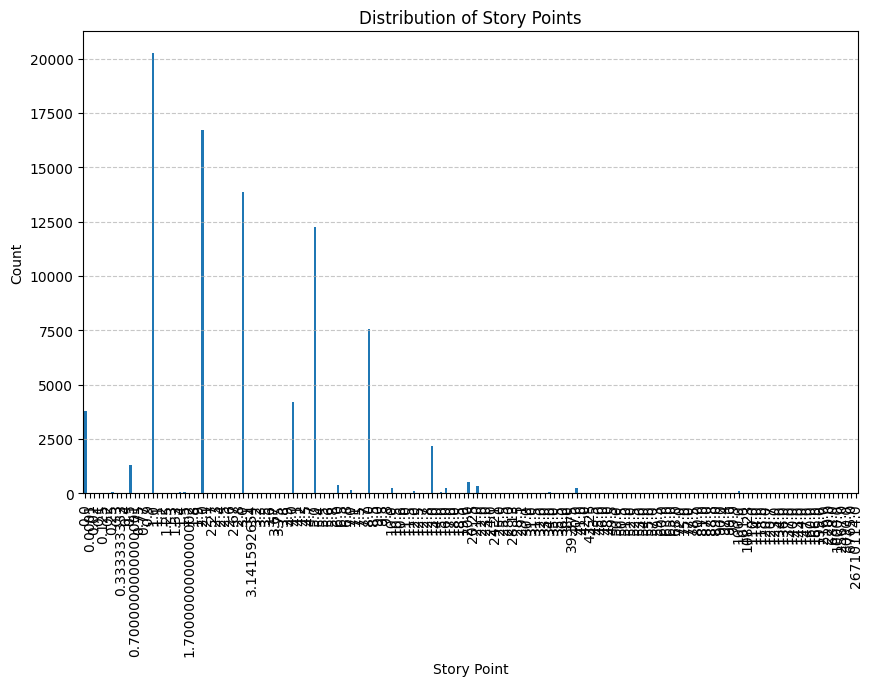

In [11]:
# Phân bố story point
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df['Story_Point'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Story Points')
plt.xlabel('Story Point')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

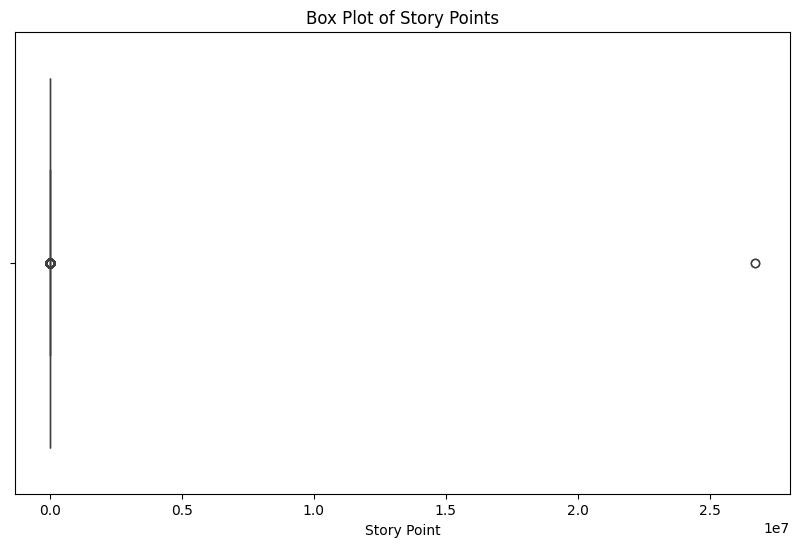

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Story_Point'])
plt.title('Box Plot of Story Points')
plt.xlabel('Story Point')
plt.show()

In [14]:
#Xử lý giá trị ngoại lai
Q1 = df['Story_Point'].quantile(0.25)
Q3 = df['Story_Point'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_filtered = df[(df['Story_Point'] >= lower_bound) & (df['Story_Point'] <= upper_bound)].copy()

# Update texts and y to reflect the filtered DataFrame
y_filtered = df_filtered["Story_Point"].values

print(f"Data shape: {df.shape} --> {df_filtered.shape}")

# LƯU Ý LÀ SỬ DỤNG: df_filtered, texts_filtered, and y_filtered cho các bước sau

Data shape: (85850, 10) --> (81499, 10)


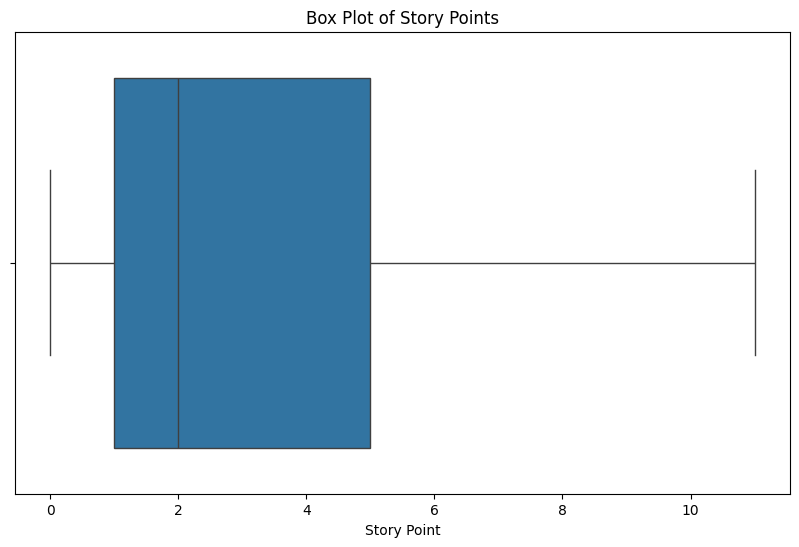

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_filtered['Story_Point'])
plt.title('Box Plot of Story Points')
plt.xlabel('Story Point')
plt.show()

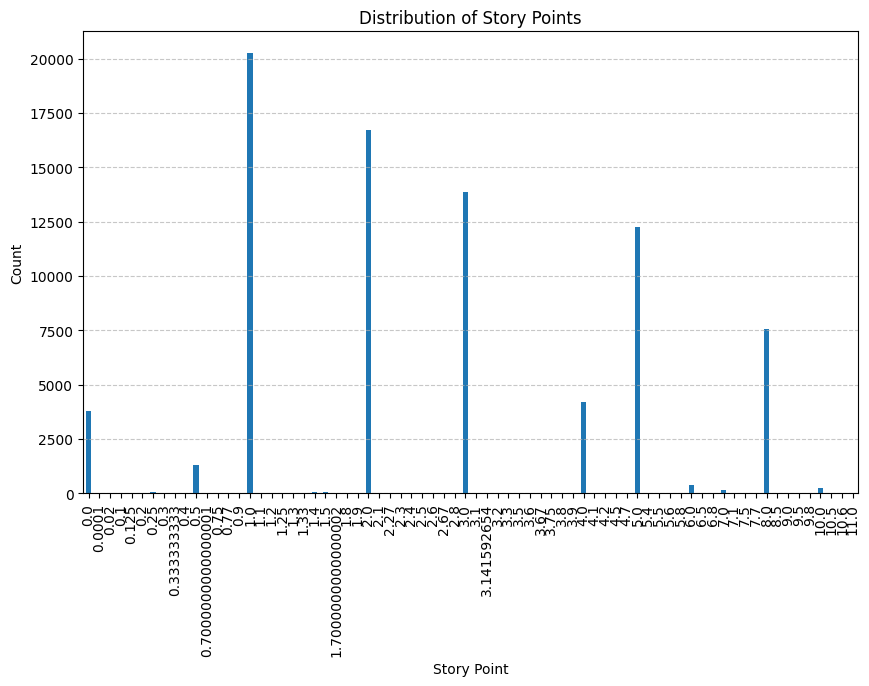

In [16]:
# Phân bố story point
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df_filtered['Story_Point'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Story Points')
plt.xlabel('Story Point')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [17]:
# Làm tròn Story_Point về số nguyên gần nhất
df_filtered["Story_Point_rounded"] = df_filtered["Story_Point"].round(0).astype(int)

# Kiểm tra nhanh phân bố sau khi làm tròn
df_filtered["Story_Point_rounded"] = df_filtered["Story_Point"].round(1)
df_filtered["Story_Point_rounded"].value_counts().sort_index()

Story_Point_rounded
0.0     3802
0.1       39
0.2      101
0.3        8
0.4       10
        ... 
9.8        6
10.0     252
10.5       4
10.6       2
11.0      26
Name: count, Length: 61, dtype: int64

In [18]:
# Quy đổi Story_Point về mức cô động (làm tròn về số nguyên gần nhất)
df_filtered["Story_Point_compact"] = df_filtered["Story_Point"].round(0).astype(int)

# Kiểm tra phân bố sau khi quy đổi
df_filtered["Story_Point_compact"].value_counts().sort_index()

Story_Point_compact
0      5281
1     20406
2     16855
3     13910
4      4294
5     12271
6       413
7       183
8      7563
9        31
10      264
11       28
Name: count, dtype: int64

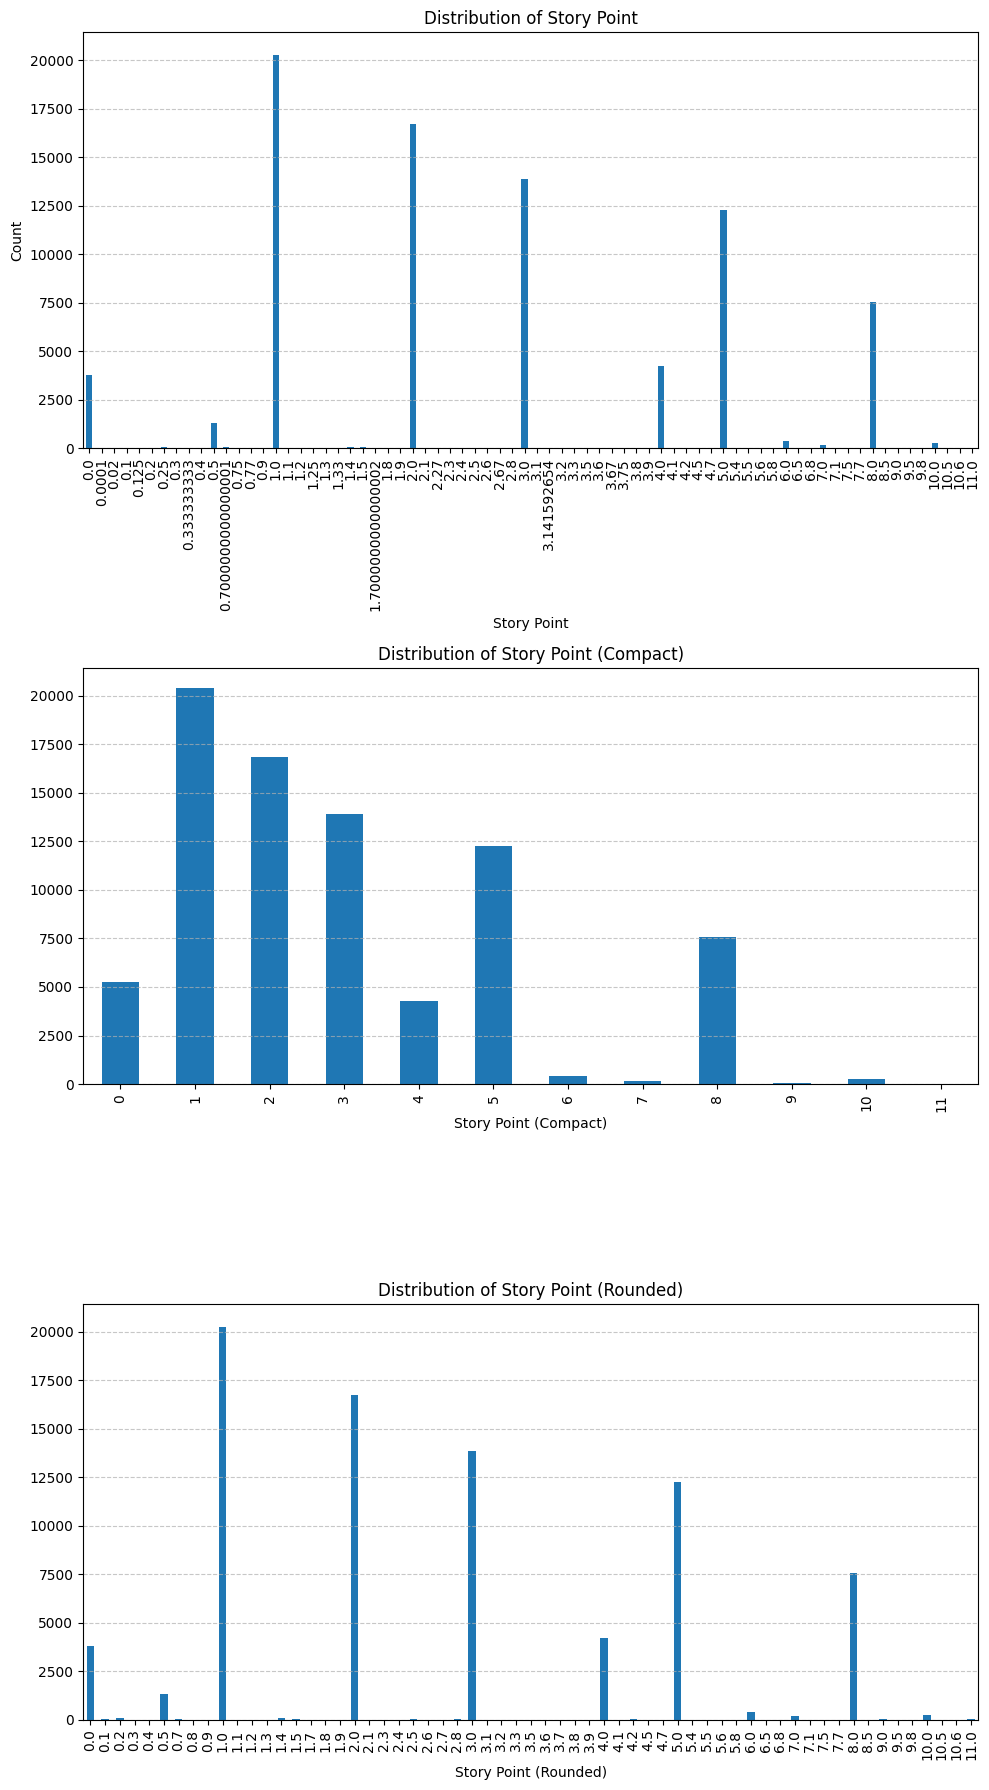

In [19]:
# Plot distributions for Story_Point, Story_Point_compact, and Story_Point_rounded
fig, axes = plt.subplots(3, 1, figsize=(10, 18), sharey=True)

df_filtered['Story_Point'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribution of Story Point')
axes[0].set_xlabel('Story Point')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

df_filtered['Story_Point_compact'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Distribution of Story Point (Compact)')
axes[1].set_xlabel('Story Point (Compact)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

df_filtered['Story_Point_rounded'].value_counts().sort_index().plot(kind='bar', ax=axes[2])
axes[2].set_title('Distribution of Story Point (Rounded)')
axes[2].set_xlabel('Story Point (Rounded)')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [20]:
df_filtered['Project_Key'] = df_filtered['Issue_Key'].str.split('-').str[0]
# Thống kê theo ProjectKey
stats = df_filtered.groupby('Project_Key').agg(
    min_storypoint=('Story_Point', 'min'),
    max_storypoint=('Story_Point', 'max'),
    count=('Story_Point', 'count')
).reset_index()
print(stats)


   Project_Key  min_storypoint  max_storypoint  count
0         ALOY             0.0             8.0    554
1       APIKIT             0.0            10.0    903
2       APSTUD             0.0            10.0   1016
3          BAM             0.0             8.0   1031
4           BE             0.0            11.0    732
5          CLI             0.0            10.0    686
6         CLOV             0.0             8.0    684
7      COMPASS             1.0             8.0    902
8    CONFCLOUD             0.0             8.0    560
9   CONFSERVER             0.0             8.0   1138
10         CWD             0.0             8.0    381
11         CXX             0.0             8.0    392
12      DAEMON             1.0             8.0    360
13    DATACASS             0.0            10.0    447
14          DM             0.0            11.0   5552
15         DNN             0.0             9.0   3918
16   DURACLOUD             0.0            10.0   1217
17         EVG             0

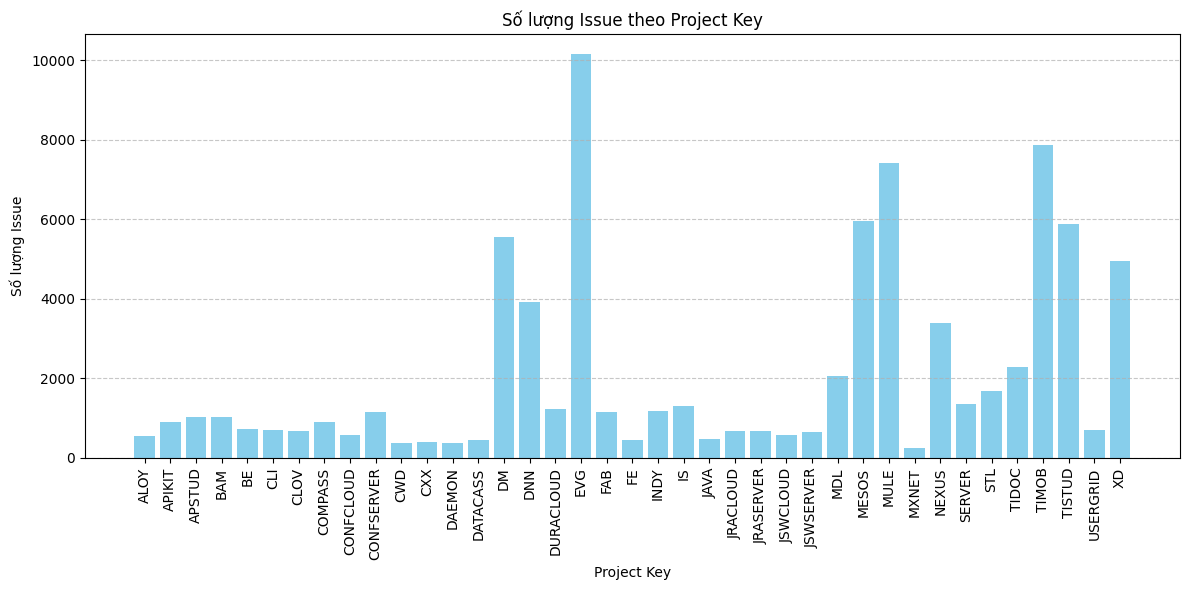

In [21]:
# Vẽ biểu đồ tổng số lượng issue theo ProjectKey
plt.figure(figsize=(12, 6))
plt.bar(stats['Project_Key'], stats['count'], color='skyblue')
plt.xlabel('Project Key')
plt.ylabel('Số lượng Issue')
plt.title('Số lượng Issue theo Project Key')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

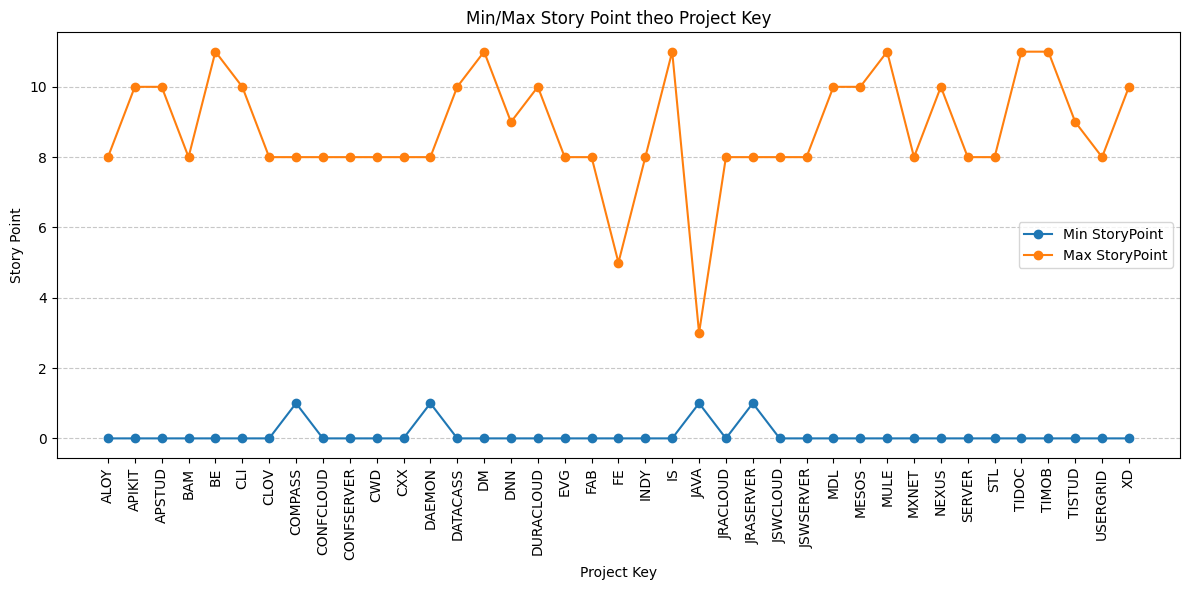

In [22]:
# Vẽ min/max storypoint theo ProjectKey
plt.figure(figsize=(12, 6))
plt.plot(stats['Project_Key'], stats['min_storypoint'], marker='o', label='Min StoryPoint')
plt.plot(stats['Project_Key'], stats['max_storypoint'], marker='o', label='Max StoryPoint')
plt.xlabel('Project Key')
plt.ylabel('Story Point')
plt.title('Min/Max Story Point theo Project Key')
plt.legend()
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [23]:
df_filtered.shape

(81499, 13)

In [24]:
df_filtered.head()

,Project_ID,Issue_Key,Type,Status,Priority,Title,Description,Description_Text,Description_Code,Story_Point,Story_Point_rounded,Story_Point_compact,Project_Key
0,1,XD-3765,FEATURE,Done,MEDIUM,"""Fix stream failover ""","""See https://github.com/spring-projects/spring...","""""""See https://github.com/spring-projects/spri...",NaN,8.0,8.0,8,XD
1,1,XD-3748,BUG,Done,MEDIUM,"""Unable to register the JMX bean MessageHistor...","""If I try to use <int:message-history/> when d...","""""""If I try to use <int:message-history/> when...",""" 2016-02-24T10:40:39+0000 1.3.1.RELEASE ERROR...",1.0,1.0,1,XD
2,1,XD-3747,IMPROVEMENT,Done,MEDIUM,"""Rabbit Bus: Expose ChannelCacheSize on Cachin...","""http://stackoverflow.com/questions/35563064/p...","""""""http://stackoverflow.com/questions/35563064...",NaN,1.0,1.0,1,XD
3,1,XD-3746,IMPROVEMENT,Done,MEDIUM,"""Update Spring Framework to 4.2.4""","""Update Spring Framework to 4.2.4""","""Update Spring Framework to 4.2.4""",NaN,1.0,1.0,1,XD
4,1,XD-3745,IMPROVEMENT,Done,MEDIUM,"""Update Spring-AMQP to 3.6, RabbitMQ Client to...","""Update to amqp-client 3.6.0 and spring-amqp 1...","""""""Update to amqp-client 3.6.0 and spring-amqp...",NaN,1.0,1.0,1,XD


In [ ]:
# !pip install -q -U sentence-transformers tqdm --quiet

In [25]:
#Encode các categorical features
from sklearn.preprocessing import LabelEncoder

# Encode Project_Key
# le_project = LabelEncoder()
# df_filtered['project_key_encoded'] = le_project.fit_transform(df_filtered['Project_Key'])

# Encode Type
le_type = LabelEncoder()
df_filtered['type_encoded'] = le_type.fit_transform(df_filtered['Type'])

# Encode Status
# le_status = LabelEncoder()
# df_filtered['status_encoded'] = le_status.fit_transform(df_filtered['Status'])

# Encode Priority
le_priority = LabelEncoder()
df_filtered['priority_encoded'] = le_priority.fit_transform(df_filtered['Priority'])

print("\nEncoded features created:")
print(f"Type: {df_filtered['type_encoded'].nunique()} unique values")
print(f"Priority: {df_filtered['priority_encoded'].nunique()} unique values")


Encoded features created:
Type: 7 unique values
Priority: 4 unique values


In [26]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81499 entries, 0 to 85849
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Project_ID           81499 non-null  int64  
 1   Issue_Key            81499 non-null  object 
 2   Type                 81499 non-null  object 
 3   Status               81499 non-null  object 
 4   Priority             81499 non-null  object 
 5   Title                81499 non-null  object 
 6   Description          81499 non-null  object 
 7   Description_Text     81499 non-null  object 
 8   Description_Code     12620 non-null  object 
 9   Story_Point          81499 non-null  float64
 10  Story_Point_rounded  81499 non-null  float64
 11  Story_Point_compact  81499 non-null  int64  
 12  Project_Key          81499 non-null  object 
 13  type_encoded         81499 non-null  int64  
 14  priority_encoded     81499 non-null  int64  
dtypes: float64(2), int64(4), object(9)
memory

In [27]:
df_filtered[['type_encoded', 'priority_encoded']].head()

,type_encoded,priority_encoded
0,3,2
1,0,2
2,4,2
3,4,2
4,4,2


In [28]:
#Tạo text features
from sklearn.preprocessing import MinMaxScaler
# Tạo đặc trưng độ dài văn bản
df_filtered['title_length'] = df_filtered['Title'].apply(lambda x: len(str(x)))
df_filtered['desc_length'] = df_filtered['Description'].apply(lambda x: len(str(x)))

# Chuẩn hóa các đặc trưng độ dài
scaler = MinMaxScaler()
df_filtered[['title_len_norm', 'desc_len_norm']] = scaler.fit_transform(
    df_filtered[['title_length', 'desc_length']]
)

In [29]:
df_filtered[['title_len_norm','desc_len_norm']].head()

,title_len_norm,desc_len_norm
0,0.020311,0.000042
1,0.080048,0.003896
2,0.071685,0.000085
3,0.034648,0.000022
4,0.057348,0.000035


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm.notebook import tqdm
import time

# Load model
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embed_model = SentenceTransformer(MODEL_NAME, device="cuda")

def get_embedding(text):
    """Embed một text thành vector"""
    emb = embed_model.encode(str(text), normalize_embeddings=True).tolist()
    return emb


print("Embedding combined Title + Description...")
embeddings_list = []
titles = df_filtered["Title"].tolist()
descriptions = df_filtered["Description"].tolist()

start_time = time.perf_counter()
for i in tqdm(range(len(titles)), desc="Embedding titles and descriptions"):
    title = titles[i]
    desc = descriptions[i]
    combined_text = f"{title} {desc}"
    emb = get_embedding(combined_text)
    embeddings_list.append(emb)
end_time = time.perf_counter()

X_combined_emb = np.array(embeddings_list)
print(f"Combined embeddings done! Shape: {X_combined_emb.shape}")

In [83]:
# Lưu embedding
np.save("../embedX/[EN_VI][MiniL12]X_combined_emb.npy", X_combined_emb)
print("Saved combined embeddings!")
print(f"- Combined: embedX/[EN_VI][MiniL12]X_combined_emb.npy")

Saved combined embeddings!
- Combined: embedX/[EN_VI][MiniL12]X_combined_emb.npy


In [30]:
import numpy as np

# Load lại embedding đã lưu để tiết kiệm thời gian cho các lần sau
X_embedded = np.load("../embedX/[EN_VI][MiniL12]X_combined_emb.npy")

extra_features = df_filtered[[
    'type_encoded',
    'priority_encoded',
    'title_len_norm',
    'desc_len_norm'
]].values

X = np.hstack([
    X_embedded, # Title và Description embeddings kết hợp
    extra_features # Đặc trưng bổ sung
])

y = df_filtered['Story_Point'].values  

print(f"X shape: {X.shape}")  # (n_samples, 384 + 4) = 772 features
print(f"y shape: {y.shape}")

X shape: (81499, 388)
y shape: (81499,)


In [31]:
import numpy as np

X = np.array(X, dtype=float)
y = np.array(y, dtype=float)

print(" Converted to numpy arrays")
print("X shape:", X.shape)
print("y shape:", y.shape)

 Converted to numpy arrays
X shape: (81499, 388)
y shape: (81499,)


In [32]:
#Chia tập dữ liệu huấn luyện
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)



Shape of X_train: (65199, 388)
Shape of X_test: (16300, 388)
Shape of y_train: (65199,)
Shape of y_test: (16300,)


In [ ]:
# !pip install lazypredict --quiet
# !pip install ipywidgets --upgrade
# !pip install --upgrade ipywidgets jupyter
# !pip install --upgrade xgboost --quiet

HÀM ĐÁNH GIÁ MODEL

In [33]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_regression(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


In [34]:
# Tập lưu kết quả
results = []

TRAIN LightGBM

In [35]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

                
lgb_model = lgb.LGBMRegressor(
    objective="regression",
    boosting_type="gbdt",
    max_depth=6,
    num_leaves=31,       
    learning_rate=0.01,
    n_estimators=10000,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=2,
    random_state=42
)


lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=500)  # log mỗi 500 rounds
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.065063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98382
[LightGBM] [Info] Number of data points in the train set: 65199, number of used features: 388
[LightGBM] [Info] Start training from score 2.970923
Training until validation scores don't improve for 50 rounds
[500]	valid_0's rmse: 2.07055	valid_0's l2: 4.28718
[1000]	valid_0's rmse: 2.0296	valid_0's l2: 4.11929
[1500]	valid_0's rmse: 2.00847	valid_0's l2: 4.03394
[2000]	valid_0's rmse: 1.99259	valid_0's l2: 3.97041
[2500]	valid_0's rmse: 1.97845	valid_0's l2: 3.91428
[3000]	valid_0's rmse: 1.96575	valid_0's l2: 3.86416
[3500]	valid_0's rmse: 1.95478	valid_0's l2: 3.82118
[4000]	valid_0's rmse: 1.94477	valid_0's l2: 3.78213
[4500]	valid_0's rmse: 1.93589	valid_0's l2: 3.74766
[5000]	valid_0's rmse: 1.92744	valid_0's l2: 3.71501
[5500]	valid_0's rmse: 1.91986	valid_0's l2: 3.68585
[6000]	valid_0

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,10000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,2


In [36]:
# LightGBM
lgb_eval = evaluate_regression("LightGBM", y_test, lgb_model.predict(X_test))
print(lgb_eval)
results.append(lgb_eval)

e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'Model': 'LightGBM', 'MAE': 1.4267805134357792, 'MSE': 3.4936916709765224, 'RMSE': np.float64(1.8691419611619986), 'R2': 0.3209873842254789}


TRAIN RANDOM FOREST

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
# Đánh giá trên tập test
rf_eval = evaluate_regression("RandomForest", y_test, rf_model.predict(X_test))
print(rf_eval)
results.append(rf_eval)

{'Model': 'RandomForest', 'MAE': 1.6356524834837642, 'MSE': 4.361824331204227, 'RMSE': np.float64(2.0884981041897612), 'R2': 0.15226241248355532}


Train Decision Tree

In [42]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42,
    min_samples_split=5,
)
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [43]:
# Đánh giá trên tập test
dt_eval = evaluate_regression("DecisionTree", y_test, dt_model.predict(X_test))
print(dt_eval)
results.append(dt_eval)

{'Model': 'DecisionTree', 'MAE': 1.7441949043902425, 'MSE': 5.185105671087385, 'RMSE': np.float64(2.277082710638194), 'R2': -0.007745530047951421}


Train XGBoostRegressor

In [37]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=10000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=500
)

[0]	validation_0-rmse:2.26091
[500]	validation_0-rmse:1.94622
[1000]	validation_0-rmse:1.88960
[1500]	validation_0-rmse:1.85353
[2000]	validation_0-rmse:1.82809
[2500]	validation_0-rmse:1.81013
[3000]	validation_0-rmse:1.79739
[3500]	validation_0-rmse:1.78787
[4000]	validation_0-rmse:1.78057
[4500]	validation_0-rmse:1.77516
[5000]	validation_0-rmse:1.77115
[5500]	validation_0-rmse:1.76773
[6000]	validation_0-rmse:1.76519
[6500]	validation_0-rmse:1.76331
[7000]	validation_0-rmse:1.76201
[7500]	validation_0-rmse:1.76097
[8000]	validation_0-rmse:1.76011
[8500]	validation_0-rmse:1.75950
[9000]	validation_0-rmse:1.75896
[9500]	validation_0-rmse:1.75860
[9999]	validation_0-rmse:1.75836


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [38]:
# Đánh giá trên tập test
xgb_eval = evaluate_regression("XGBoost", y_test, xgb_model.predict(X_test))
print(xgb_eval)
results.append(xgb_eval)

{'Model': 'XGBoost', 'MAE': 1.3174629277968974, 'MSE': 3.0918467474255, 'RMSE': np.float64(1.7583647936152214), 'R2': 0.39908751393721886}


In [39]:
for key, value in xgb_eval.items():
    print(f"{key}: {value}")

Model: XGBoost
MAE: 1.3174629277968974
MSE: 3.0918467474255
RMSE: 1.7583647936152214
R2: 0.39908751393721886


Train CatBoost

In [45]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=10000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    early_stopping_rounds=50,
    verbose=500
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test)
)



0:	learn: 2.2221801	test: 2.2642986	best: 2.2642986 (0)	total: 116ms	remaining: 19m 22s
500:	learn: 1.9826181	test: 2.0702213	best: 2.0702213 (500)	total: 21.8s	remaining: 6m 53s
1000:	learn: 1.8746585	test: 2.0297354	best: 2.0297354 (1000)	total: 42.7s	remaining: 6m 23s
1500:	learn: 1.7862627	test: 2.0041861	best: 2.0041861 (1500)	total: 1m 3s	remaining: 5m 59s
2000:	learn: 1.7078985	test: 1.9842168	best: 1.9842168 (2000)	total: 1m 24s	remaining: 5m 39s
2500:	learn: 1.6370579	test: 1.9679335	best: 1.9679335 (2500)	total: 1m 46s	remaining: 5m 18s
3000:	learn: 1.5706578	test: 1.9537617	best: 1.9537617 (3000)	total: 2m 7s	remaining: 4m 57s
3500:	learn: 1.5099152	test: 1.9409026	best: 1.9409026 (3500)	total: 2m 28s	remaining: 4m 35s
4000:	learn: 1.4518472	test: 1.9283928	best: 1.9283928 (4000)	total: 2m 49s	remaining: 4m 13s
4500:	learn: 1.3970949	test: 1.9176132	best: 1.9176132 (4500)	total: 3m 10s	remaining: 3m 52s
5000:	learn: 1.3460551	test: 1.9075575	best: 1.9075575 (5000)	total: 3m 

In [46]:
cb_eval = evaluate_regression("CatBoost", y_test, cat_model.predict(X_test))
print(cb_eval)
results.append(cb_eval)

{'Model': 'CatBoost', 'MAE': 1.3979676468650506, 'MSE': 3.393486731836238, 'RMSE': np.float64(1.8421418869990005), 'R2': 0.340462605351719}


In [47]:
results

[{'Model': 'LightGBM',
  'MAE': 1.4267805134357792,
  'MSE': 3.4936916709765224,
  'RMSE': np.float64(1.8691419611619986),
  'R2': 0.3209873842254789},
 {'Model': 'XGBoost',
  'MAE': 1.3174629277968974,
  'MSE': 3.0918467474255,
  'RMSE': np.float64(1.7583647936152214),
  'R2': 0.39908751393721886},
 {'Model': 'RandomForest',
  'MAE': 1.6356524834837642,
  'MSE': 4.361824331204227,
  'RMSE': np.float64(2.0884981041897612),
  'R2': 0.15226241248355532},
 {'Model': 'DecisionTree',
  'MAE': 1.7441949043902425,
  'MSE': 5.185105671087385,
  'RMSE': np.float64(2.277082710638194),
  'R2': -0.007745530047951421},
 {'Model': 'CatBoost',
  'MAE': 1.3979676468650506,
  'MSE': 3.393486731836238,
  'RMSE': np.float64(1.8421418869990005),
  'R2': 0.340462605351719}]

Plot biểu đồ

In [48]:
import numpy as np
import matplotlib.pyplot as plt

In [49]:
import matplotlib.pyplot as plt

def plot_metric(results, metric_key, title, ylabel, ylim=None):
    """
    Plot bar chart và line chart cho 1 metric
    
    results   : list[dict]
    metric_key: key của metric (vd: 'RMSE', 'R2')
    title     : tiêu đề chung
    ylabel    : nhãn trục y
    ylim      : tuple (min, max) hoặc None
    """

    model_names = [res["Model"] for res in results]
    values = [res[metric_key] for res in results]

    # ===== Bar chart =====
    plt.figure(figsize=(10, 6))
    plt.bar(model_names, values, alpha=0.7)
    plt.title(f'{title} (Bar Chart)')
    plt.xlabel('Model')
    plt.ylabel(ylabel)
    if ylim:
        plt.ylim(*ylim)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # ===== Line chart =====
    plt.figure(figsize=(10, 6))
    plt.plot(model_names, values, marker='o', linewidth=2)
    plt.title(f'{title} (Line Chart)')
    plt.xlabel('Model')
    plt.ylabel(ylabel)
    if ylim:
        plt.ylim(*ylim)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


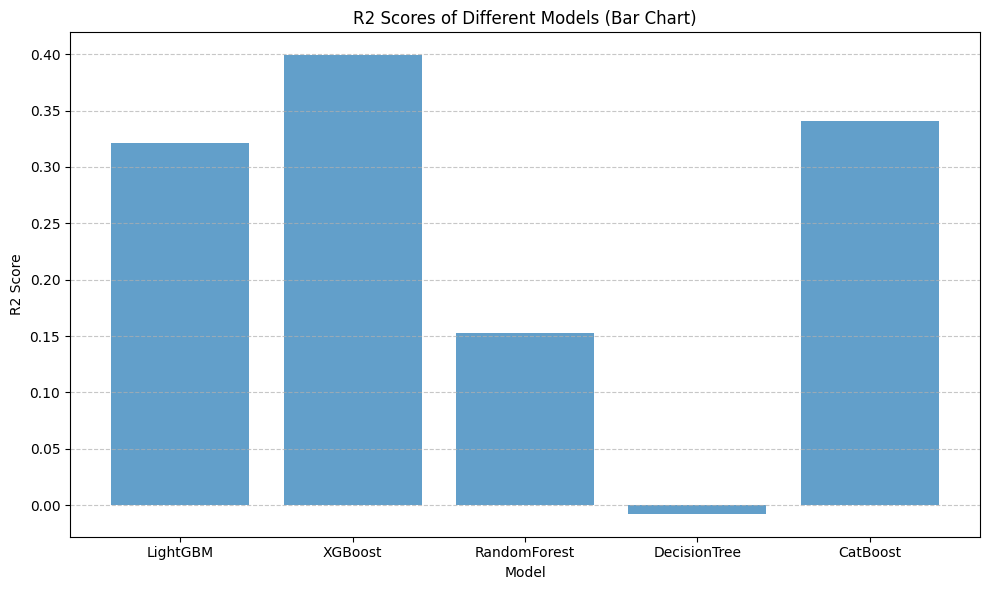

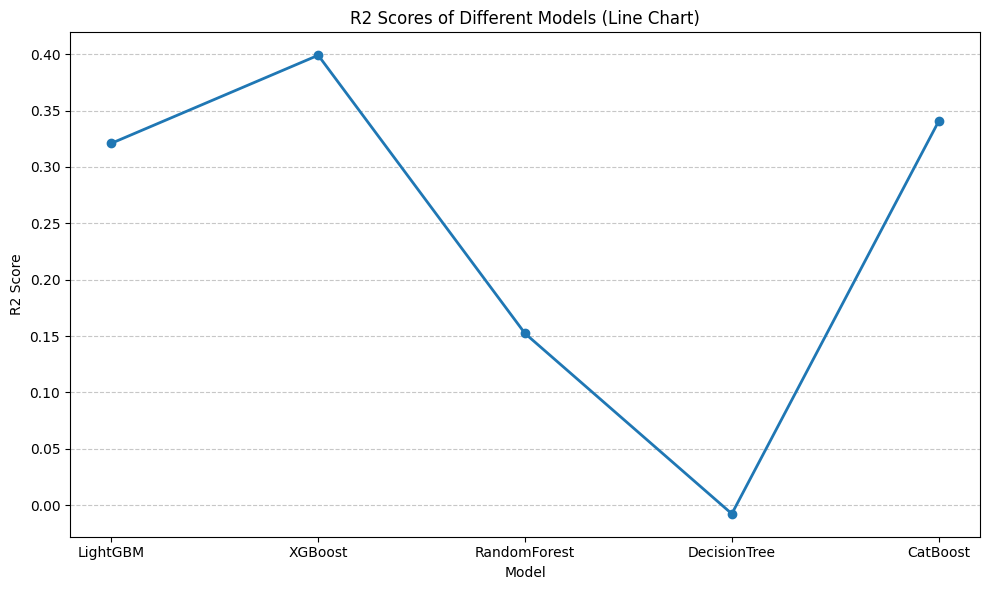

In [50]:
#Plot R2 Score
plot_metric(
    results,
    metric_key="R2",
    title="R2 Scores of Different Models",
    ylabel="R2 Score",
    # ylim=(0, 1)
)


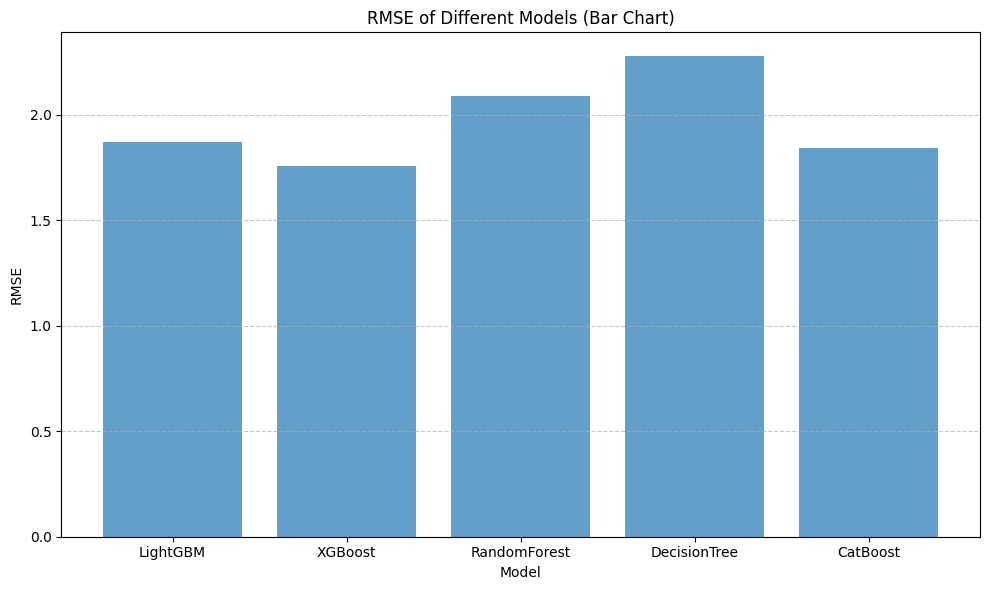

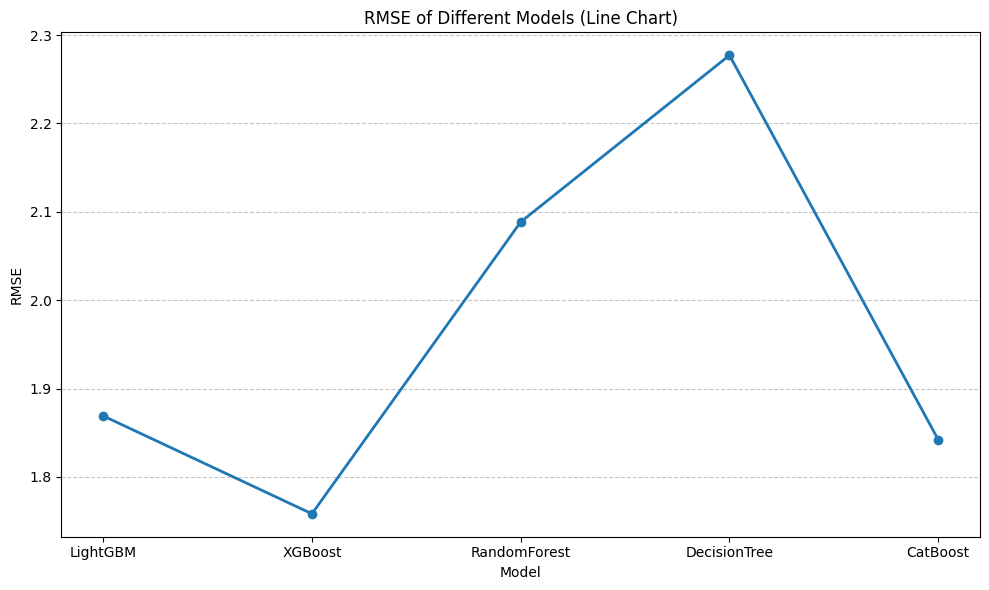

In [51]:
#Plot RMSE Score
plot_metric(
    results,
    metric_key="RMSE",
    title="RMSE of Different Models",
    ylabel="RMSE",
    ylim=None
)

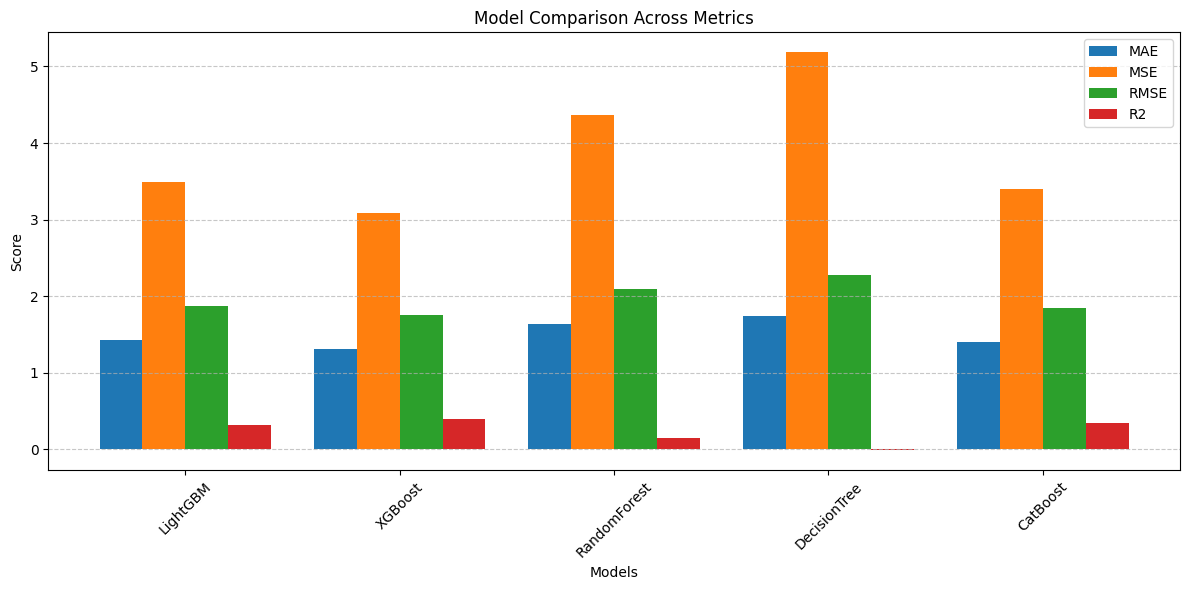

In [52]:


metrics = ['MAE', 'MSE', 'RMSE', 'R2']
model_names = [res['Model'] for res in results]

# lấy giá trị metric
metric_values = {
    metric.strip(): [res[metric] for res in results]
    for metric in metrics
}

x = np.arange(len(model_names))  # vị trí model
width = 0.2 

plt.figure(figsize=(12, 6))

for i, (metric, values) in enumerate(metric_values.items()):
    plt.bar(x + i * width, values, width, label=metric)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Comparison Across Metrics')
plt.xticks(x + width * (len(metrics) - 1) / 2, model_names, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



TEST DỰ ĐOÁN

In [53]:
from sentence_transformers import SentenceTransformer

# Import embed model
embed_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", device="cuda")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [54]:
def build_feature_vector(
    title: str,
    desc: str,
    type_val: str,
    priority_val: str,
    embed_model,
    scaler,
    le_type,
    le_priority
):
    t_text = str(title) if title else ""
    d_text = str(desc) if desc else ""
    combined_text = f"{t_text} {d_text}"

    combined_emb = embed_model.encode(
        combined_text,
        normalize_embeddings=True
    )

    lengths = np.array([[len(t_text), len(d_text)]])
    title_len_norm, desc_len_norm = scaler.transform(lengths)[0]

    type_encoded = le_type.transform([type_val])[0]
    priority_encoded = le_priority.transform([priority_val])[0]

    extra_features = [
        type_encoded,
        priority_encoded,
        title_len_norm,
        desc_len_norm
    ]

    return np.concatenate([combined_emb, extra_features]).reshape(1, -1)

In [55]:
def predict_story_point_multi(
    models: dict,
    title: str,
    desc: str,
    type_val: str,
    priority_val: str,
    embed_model,
    scaler,
    le_type,
    le_priority
):
    X_input = build_feature_vector(
        title,
        desc,
        type_val,
        priority_val,
        embed_model,
        scaler,
        le_type,
        le_priority
    )

    return {
        name: round(float(model.predict(X_input)[0]), 2)
        for name, model in models.items()
    }


In [56]:
models_dict = {
    "LightGBM": lgb_model,
    "RandomForest": rf_model,
    "DecisionTree": dt_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_model
}

In [57]:
# Danh sách test tiếng Việt
# Danh sách test tiếng Việt (Type + Priority = UPPERCASE)
test_cases = [
    (
        "Lỗi đăng nhập",
        "Người dùng không thể đăng nhập bằng Google trên ứng dụng di động.",
        "JSW",
        "BUG",
        "HIGH"
    ),
    (
        "Thêm tooltip UI",
        "Thêm tooltip cho nút tạo task để người dùng hiểu rõ chức năng.",
        "TIDOC",
        "OTHER",
        "MEDIUM"
    ),
    (
        "Tối ưu backend",
        "Refactor toàn bộ API, cải thiện tốc độ phản hồi cho hệ thống.",
        "MDL",
        "IMPROVEMENT",
        "HIGH"
    ),
    (
        "Sửa lỗi crash khi upload file",
        "Ứng dụng bị crash khi upload file trên trình duyệt Safari.",
        "MDL",
        "BUG",
        "URGENT"
    ),
    (
        "Thêm phân quyền mới",
        "Thêm quyền 'Supervisor' để xem báo cáo nhưng không được chỉnh sửa task.",
        "TIDOC",
        "FEATURE",
        "MEDIUM"
    ),
    (
        "Cải thiện tốc độ tìm kiếm",
        "Tối ưu query và thêm caching để kết quả tìm kiếm hiển thị nhanh hơn.",
        "JSW",
        "IMPROVEMENT",
        "HIGH"
    ),
    (
        "Fix lỗi hiển thị UI",
        "Icon menu bị lệch vị trí trên màn hình iPhone 12.",
        "JSW",
        "BUG",
        "LOW"
    ),
    (
        "Thêm login bằng Facebook",
        "Người dùng có thể đăng nhập bằng tài khoản Facebook.",
        "JSW",
        "FEATURE",
        "MEDIUM"
    ),
    (
        "Phát triển dashboard thống kê",
        "Xây dựng dashboard hiển thị KPI dự án theo thời gian thực.",
        "TIDOC",
        "FEATURE",
        "HIGH"
    ),
    (
        "Sửa lỗi email không gửi",
        "Hệ thống không gửi email xác thực đối với domain Outlook.",
        "JSW",
        "BUG",
        "URGENT"
    )
]
print("Kết quả dự đoán Story Point:")
rows = []

for title, desc, project_key, type_val, priority_val in test_cases:
    preds = predict_story_point_multi(
        models_dict,
        title,
        desc,
        type_val,
        priority_val,
        embed_model,
        scaler,
        le_type,
        le_priority
    )

    row = {
        "Project": project_key,
        "Title": title,
        "Description": desc,
        "Type": type_val,
        "Priority": priority_val
    }

    for model_name, sp in preds.items():
        row[model_name] = sp

    rows.append(row)

df_result = pd.DataFrame(rows)


Kết quả dự đoán Story Point:


e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\

In [58]:
df_result

,Project,Title,Description,Type,Priority,LightGBM,RandomForest,DecisionTree,XGBoost,CatBoost
0,JSW,Lỗi đăng nhập,Người dùng không thể đăng nhập bằng Google trê...,BUG,HIGH,2.95,2.65,2.14,3.00,2.48
1,TIDOC,Thêm tooltip UI,Thêm tooltip cho nút tạo task để người dùng hi...,OTHER,MEDIUM,2.41,3.55,7.45,3.28,1.27
2,MDL,Tối ưu backend,"Refactor toàn bộ API, cải thiện tốc độ phản hồ...",IMPROVEMENT,HIGH,3.32,3.23,2.42,3.54,4.20
3,MDL,Sửa lỗi crash khi upload file,Ứng dụng bị crash khi upload file trên trình d...,BUG,URGENT,4.14,3.20,2.80,3.05,3.52
4,TIDOC,Thêm phân quyền mới,Thêm quyền 'Supervisor' để xem báo cáo nhưng k...,FEATURE,MEDIUM,1.57,2.26,2.13,1.04,1.01
5,JSW,Cải thiện tốc độ tìm kiếm,Tối ưu query và thêm caching để kết quả tìm ki...,IMPROVEMENT,HIGH,2.74,2.52,3.10,2.58,3.39
6,JSW,Fix lỗi hiển thị UI,Icon menu bị lệch vị trí trên màn hình iPhone 12.,BUG,LOW,1.45,2.62,3.10,1.11,1.75
7,JSW,Thêm login bằng Facebook,Người dùng có thể đăng nhập bằng tài khoản Fac...,FEATURE,MEDIUM,2.09,2.65,3.10,1.88,1.39
8,TIDOC,Phát triển dashboard thống kê,Xây dựng dashboard hiển thị KPI dự án theo thờ...,FEATURE,HIGH,3.44,3.51,2.50,4.03,3.46
9,JSW,Sửa lỗi email không gửi,Hệ thống không gửi email xác thực đối với doma...,BUG,URGENT,2.71,3.91,2.45,3.12,2.84


In [59]:
print(le_priority.classes_)
print(le_type.classes_)

['HIGH' 'LOW' 'MEDIUM' 'URGENT']
['BUG' 'DOCUMENTATION' 'ENHANCEMENT' 'FEATURE' 'IMPROVEMENT' 'MAINTENANCE'
 'OTHER']


In [60]:
# Test cases song ngữ (theo cặp, CÙNG Type + Priority)
test_pairs = [
    (
        ("Lỗi đăng nhập", "Người dùng không thể đăng nhập bằng Google trên ứng dụng di động.", "JSW"),
        ("Login error", "Users cannot log in with Google on the mobile app.", "JSW"),
        "BUG",
        "HIGH"
    ),
    (
        ("Thêm tooltip UI", "Thêm tooltip cho nút tạo task để người dùng hiểu rõ chức năng.", "TIDOC"),
        ("Add UI tooltip", "Add tooltip for the create task button to help users understand its function.", "TIDOC"),
        "OTHER",
        "MEDIUM"
    ),
    (
        ("Tối ưu backend", "Refactor toàn bộ API, cải thiện tốc độ phản hồi cho hệ thống.", "MDL"),
        ("Optimize backend", "Refactor all APIs to improve system response speed.", "MDL"),
        "IMPROVEMENT",
        "HIGH"
    ),
    (
        ("Sửa lỗi crash khi upload file", "Ứng dụng bị crash khi upload file trên trình duyệt Safari.", "MDL"),
        ("Fix crash on file upload", "The app crashes when uploading files on Safari browser.", "MDL"),
        "BUG",
        "URGENT"
    ),
    (
        ("Thêm phân quyền mới", "Thêm quyền 'Supervisor' để xem báo cáo nhưng không được chỉnh sửa task.", "TIDOC"),
        ("Add new permission", "Add 'Supervisor' role to view reports but not edit tasks.", "TIDOC"),
        "FEATURE",
        "MEDIUM"
    ),
    (
        ("Cải thiện tốc độ tìm kiếm", "Tối ưu query và thêm caching để kết quả tìm kiếm hiển thị nhanh hơn.", "JSW"),
        ("Improve search speed", "Optimize queries and add caching to speed up search results.", "JSW"),
        "IMPROVEMENT",
        "HIGH"
    ),
    (
        ("Fix lỗi hiển thị UI", "Icon menu bị lệch vị trí trên màn hình iPhone 12.", "JSW"),
        ("Fix UI display issue", "Menu icon is misaligned on iPhone 12 screen.", "JSW"),
        "BUG",
        "LOW"
    ),
    (
        ("Thêm login bằng Facebook", "Người dùng có thể đăng nhập bằng tài khoản Facebook.", "JSW"),
        ("Add login with Facebook", "Users can log in using their Facebook accounts.", "JSW"),
        "FEATURE",
        "MEDIUM"
    ),
    (
        ("Phát triển dashboard thống kê", "Xây dựng dashboard hiển thị KPI dự án theo thời gian thực.", "TIDOC"),
        ("Develop statistics dashboard", "Build a dashboard to display project KPIs in real-time.", "TIDOC"),
        "FEATURE",
        "HIGH"
    ),
    (
        ("Sửa lỗi email không gửi", "Hệ thống không gửi email xác thực đối với domain Outlook.", "JSW"),
        ("Fix email sending issue", "The system fails to send verification emails for Outlook domain.", "JSW"),
        "BUG",
        "URGENT"
    )
]


In [61]:
rows = []

for (title_vn, desc_vn, key), (title_en, desc_en, _), type_val, priority_val in test_pairs:
    pred_vn = predict_story_point_multi(
        models_dict,
        title_vn,
        desc_vn,
        type_val,
        priority_val,
        embed_model,
        scaler,
        le_type,
        le_priority
    )

    pred_en = predict_story_point_multi(
        models_dict,
        title_en,
        desc_en,
        type_val,
        priority_val,
        embed_model,
        scaler,
        le_type,
        le_priority
    )

    for m in models_dict.keys():
        rows.append({
            "Project": key,
            "Model": m,
            "Type": type_val,
            "Priority": priority_val,
            "Title_vn": title_vn,
            "Title_en": title_en,
            "SP_VN": pred_vn[m],
            "SP_EN": pred_en[m],
            "Độ lệch": round(abs(pred_vn[m] - pred_en[m]), 2)
        })

df_long = pd.DataFrame(rows)
df_long


e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\

,Project,Model,Type,Priority,Title_vn,Title_en,SP_VN,SP_EN,Độ lệch
0,JSW,LightGBM,BUG,HIGH,Lỗi đăng nhập,Login error,2.95,2.54,0.41
1,JSW,RandomForest,BUG,HIGH,Lỗi đăng nhập,Login error,2.65,3.39,0.74
2,JSW,DecisionTree,BUG,HIGH,Lỗi đăng nhập,Login error,2.14,2.11,0.03
3,JSW,XGBoost,BUG,HIGH,Lỗi đăng nhập,Login error,3.00,2.36,0.64
4,JSW,CatBoost,BUG,HIGH,Lỗi đăng nhập,Login error,2.48,2.72,0.24
5,TIDOC,LightGBM,OTHER,MEDIUM,Thêm tooltip UI,Add UI tooltip,2.41,2.68,0.27
6,TIDOC,RandomForest,OTHER,MEDIUM,Thêm tooltip UI,Add UI tooltip,3.55,3.80,0.25
7,TIDOC,DecisionTree,OTHER,MEDIUM,Thêm tooltip UI,Add UI tooltip,7.45,4.61,2.84
8,TIDOC,XGBoost,OTHER,MEDIUM,Thêm tooltip UI,Add UI tooltip,3.28,1.98,1.30
9,TIDOC,CatBoost,OTHER,MEDIUM,Thêm tooltip UI,Add UI tooltip,1.27,0.82,0.45


In [63]:
# Chỉ giữ kết quả XGBoost trong bảng test
df_result_xgb = df_result[['Project', 'Title', 'Description', 'Type', 'Priority', 'XGBoost']]
df_result_xgb

,Project,Title,Description,Type,Priority,XGBoost
0,JSW,Lỗi đăng nhập,Người dùng không thể đăng nhập bằng Google trê...,BUG,HIGH,3.00
1,TIDOC,Thêm tooltip UI,Thêm tooltip cho nút tạo task để người dùng hi...,OTHER,MEDIUM,3.28
2,MDL,Tối ưu backend,"Refactor toàn bộ API, cải thiện tốc độ phản hồ...",IMPROVEMENT,HIGH,3.54
3,MDL,Sửa lỗi crash khi upload file,Ứng dụng bị crash khi upload file trên trình d...,BUG,URGENT,3.05
4,TIDOC,Thêm phân quyền mới,Thêm quyền 'Supervisor' để xem báo cáo nhưng k...,FEATURE,MEDIUM,1.04
5,JSW,Cải thiện tốc độ tìm kiếm,Tối ưu query và thêm caching để kết quả tìm ki...,IMPROVEMENT,HIGH,2.58
6,JSW,Fix lỗi hiển thị UI,Icon menu bị lệch vị trí trên màn hình iPhone 12.,BUG,LOW,1.11
7,JSW,Thêm login bằng Facebook,Người dùng có thể đăng nhập bằng tài khoản Fac...,FEATURE,MEDIUM,1.88
8,TIDOC,Phát triển dashboard thống kê,Xây dựng dashboard hiển thị KPI dự án theo thờ...,FEATURE,HIGH,4.03
9,JSW,Sửa lỗi email không gửi,Hệ thống không gửi email xác thực đối với doma...,BUG,URGENT,3.12


In [64]:
# Chỉ giữ kết quả XGBoost trong bảng test result long
df_long_xgb = df_long[df_long['Model'] == 'XGBoost'].reset_index(drop=True)
df_long_xgb

,Project,Model,Type,Priority,Title_vn,Title_en,SP_VN,SP_EN,Độ lệch
0,JSW,XGBoost,BUG,HIGH,Lỗi đăng nhập,Login error,3.00,2.36,0.64
1,TIDOC,XGBoost,OTHER,MEDIUM,Thêm tooltip UI,Add UI tooltip,3.28,1.98,1.30
2,MDL,XGBoost,IMPROVEMENT,HIGH,Tối ưu backend,Optimize backend,3.54,4.28,0.74
3,MDL,XGBoost,BUG,URGENT,Sửa lỗi crash khi upload file,Fix crash on file upload,3.05,3.12,0.07
4,TIDOC,XGBoost,FEATURE,MEDIUM,Thêm phân quyền mới,Add new permission,1.04,1.87,0.83
5,JSW,XGBoost,IMPROVEMENT,HIGH,Cải thiện tốc độ tìm kiếm,Improve search speed,2.58,2.54,0.04
6,JSW,XGBoost,BUG,LOW,Fix lỗi hiển thị UI,Fix UI display issue,1.11,2.17,1.06
7,JSW,XGBoost,FEATURE,MEDIUM,Thêm login bằng Facebook,Add login with Facebook,1.88,1.76,0.12
8,TIDOC,XGBoost,FEATURE,HIGH,Phát triển dashboard thống kê,Develop statistics dashboard,4.03,3.76,0.27
9,JSW,XGBoost,BUG,URGENT,Sửa lỗi email không gửi,Fix email sending issue,3.12,3.12,0.00


Lưu mô hình XGBoost để sử dụng

In [ ]:
import os
import joblib
BASE_DIR = "models/minil12"
model_dir = os.path.join(BASE_DIR, "new")
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "xgb_sp.pkl")
joblib.dump(xgb_model, model_path)
print(f"Saved: {model_path}")



In [28]:
BASE_DIR = "scaler"
shared_dir = os.path.join(BASE_DIR, "shared")
os.makedirs(shared_dir, exist_ok=True)

joblib.dump(scaler, os.path.join(shared_dir, "scaler.pkl"))
joblib.dump(le_type, os.path.join(shared_dir, "le_type.pkl"))
joblib.dump(le_priority, os.path.join(shared_dir, "le_priority.pkl"))

print("Saved scaler, le_type, le_priority.")

Saved scaler, le_type, le_priority.


In [ ]:
import os
import joblib

BASE_DIR = "models/minil12"
PREFIX = "[MiniL12]"

models_dict = {
    "LightGBM": lgb_model,
    "RandomForest": rf_model,
    "DecisionTree": dt_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_model
}

# Tạo thư mục gốc
os.makedirs(BASE_DIR, exist_ok=True)

# Lưu từng model vào folder riêng
for model_name, model in models_dict.items():
    model_dir = os.path.join(BASE_DIR, model_name)
    os.makedirs(model_dir, exist_ok=True)

    model_path = os.path.join(
        model_dir, f"{PREFIX}_{model_name}.pkl"
    )
    joblib.dump(model, model_path)
    print(f"Đã lưu: {model_path}")

# Lưu scaler (dùng chung)
shared_dir = os.path.join(BASE_DIR, "shared")
os.makedirs(shared_dir, exist_ok=True)

scaler_path = os.path.join(shared_dir, f"{PREFIX}_scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"Đã lưu: {scaler_path}")
